In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('preprocessed_data.csv')   


In [3]:
df.rename(columns={'Loan_Default': 'Loan_Status'}, inplace=True)

X = df.drop(columns=['Loan_Status'])
y = df['Loan_Status']

In [4]:
X = pd.get_dummies(X, drop_first=True)

In [5]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

In [7]:
print(X_train.shape)
print(X_test.shape)

(491, 13)
(123, 13)


In [8]:
#training the model
from sklearn.linear_model import LogisticRegression

# create model
model = LogisticRegression()

# train model
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [9]:
# PREDICTION
y_pred = model.predict(X_test)

In [10]:
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [11]:
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score,f1_score

In [12]:
# Checking accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7886178861788617


In [13]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[79  1]
 [25 18]]


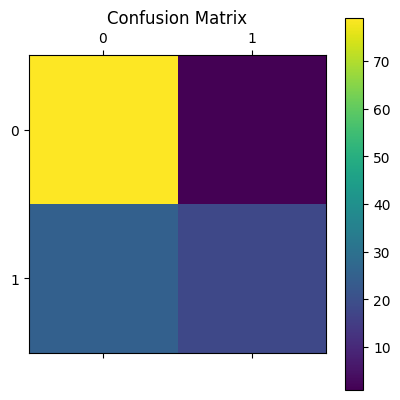

In [14]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.matshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()

In [15]:
# Checking precision
precision = precision_score(y_test, y_pred)
print("Precision:", precision)

Precision: 0.9473684210526315


In [16]:
#checking recall score
recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Recall: 0.4186046511627907


In [17]:
#checking f1 score
f1= f1_score(y_test, y_pred)
print("F1 Score:", f1)

F1 Score: 0.5806451612903226


In [18]:
#ROC-AUC Score (Measures overall model performance in classification.)

from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_pred)
print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.7030523255813954


In [19]:
print("Accuracy:", accuracy_score(y_test, y_pred)*100, "%")

Accuracy: 78.86178861788618 %


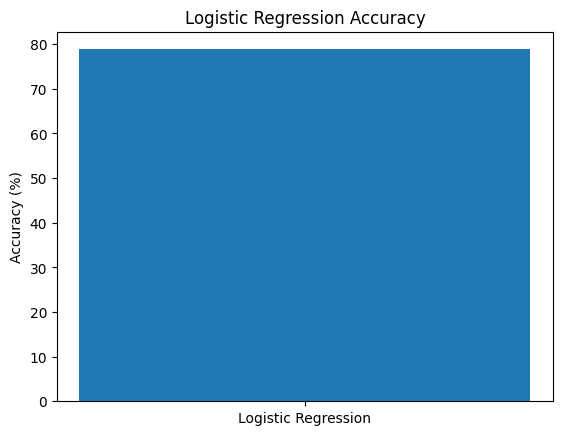

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred) * 100

plt.bar(["Logistic Regression"], [acc])
plt.ylabel("Accuracy (%)")
plt.title("Logistic Regression Accuracy")
plt.show()

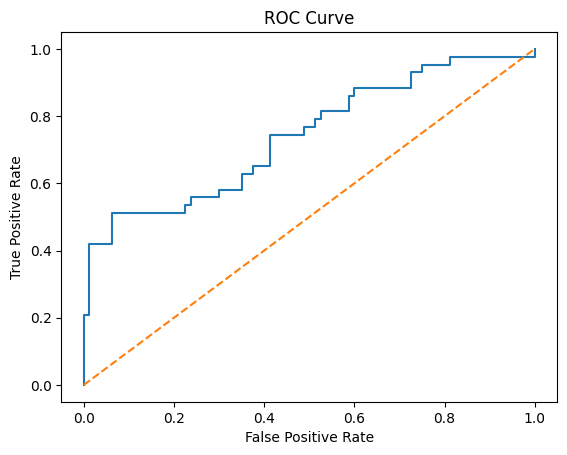

In [21]:
#roc cruve showing weak performance of model
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# probabilities for positive class
y_prob = model.predict_proba(X_test)[:, 1]

# compute ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# plot
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [22]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.90)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

In [23]:
#SVM
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

In [24]:
# Import libraries
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# Create SVM model
svm = SVC(kernel='rbf', C=1, gamma='scale')

# Train model
svm.fit(X_train, y_train)

# Prediction
y_pred = svm.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
print(confusion_matrix(y_test, y_pred))

# Classification Report
print(classification_report(y_test, y_pred))

Accuracy: 0.7967479674796748
[[80  0]
 [25 18]]
              precision    recall  f1-score   support

           0       0.76      1.00      0.86        80
           1       1.00      0.42      0.59        43

    accuracy                           0.80       123
   macro avg       0.88      0.71      0.73       123
weighted avg       0.85      0.80      0.77       123



In [25]:
#KMEANS
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
import numpy as np

In [26]:
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X)   

In [27]:
labels = np.zeros_like(clusters)  

In [28]:
accuracy = accuracy_score(y, labels)

print("KMeans Accuracy:", accuracy)   

KMeans Accuracy: 0.6872964169381107


In [29]:
sil_score = silhouette_score(X, clusters)
print("Silhouette Score:", sil_score)

Silhouette Score: 0.14192824109468752


In [30]:
#RANDOM FOREST
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# train
model.fit(X_train, y_train)

# predict
y_pred = model.predict(X_test)

# accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Random Forest Accuracy:", accuracy)

Random Forest Accuracy: 0.7723577235772358


In [31]:
#DECISION TREE
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# model
model = DecisionTreeClassifier(random_state=42)

# train
model.fit(X_train, y_train)

# predict
y_pred = model.predict(X_test)

# accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Decision Tree Accuracy:", accuracy)

Decision Tree Accuracy: 0.6829268292682927


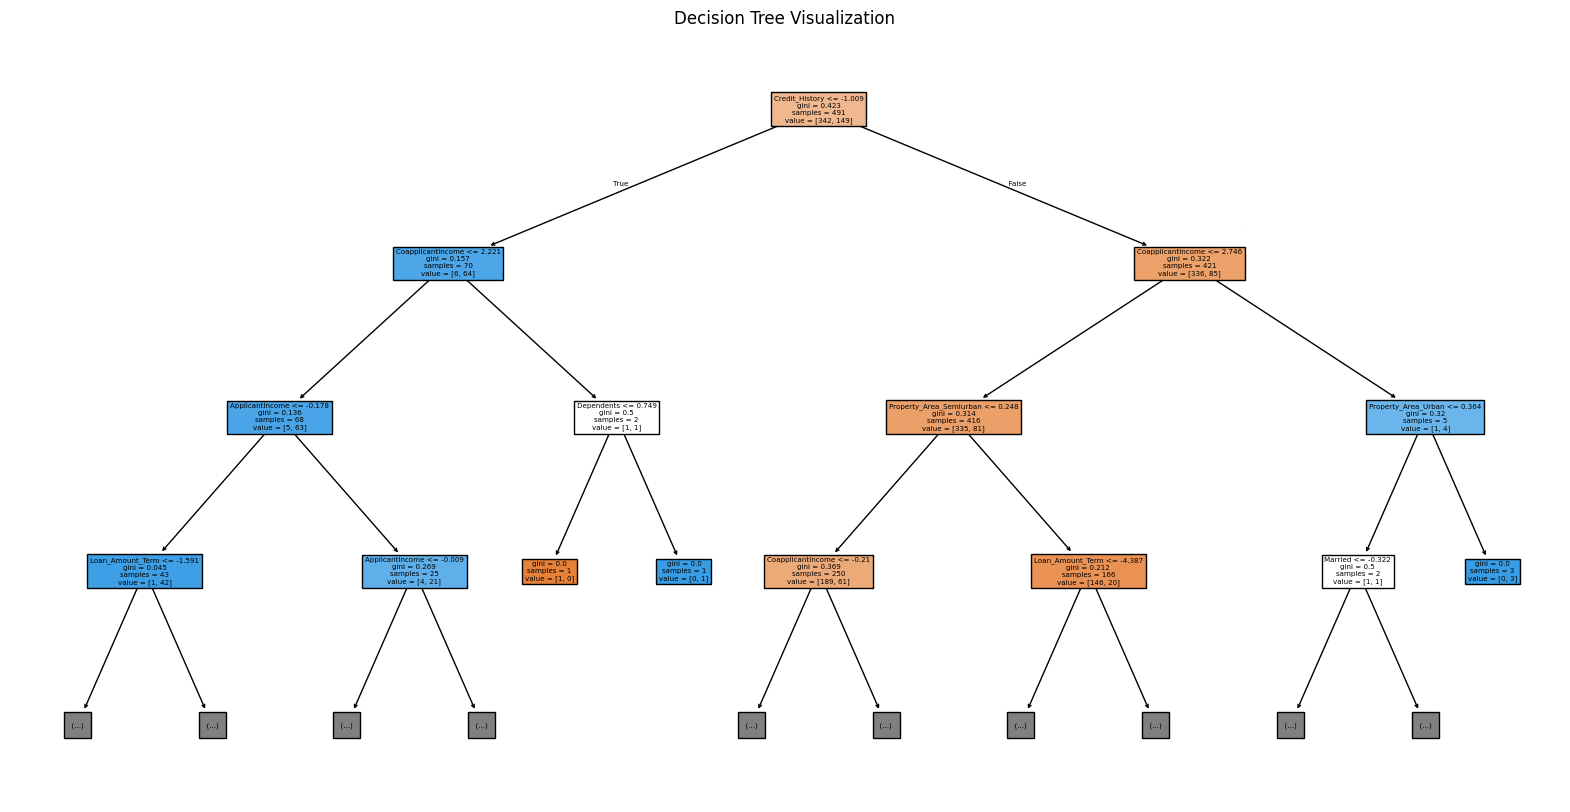

In [32]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(model, filled=True, feature_names=X.columns, max_depth=3)
plt.title("Decision Tree Visualization")
plt.show()

In [33]:
#LINEAR REGRESSION
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# model
model = LinearRegression()

# train
model.fit(X_train, y_train)

# predict
y_pred = model.predict(X_test)

# evaluation
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 0.16457562981219137
R2 Score: 0.2762021210963246


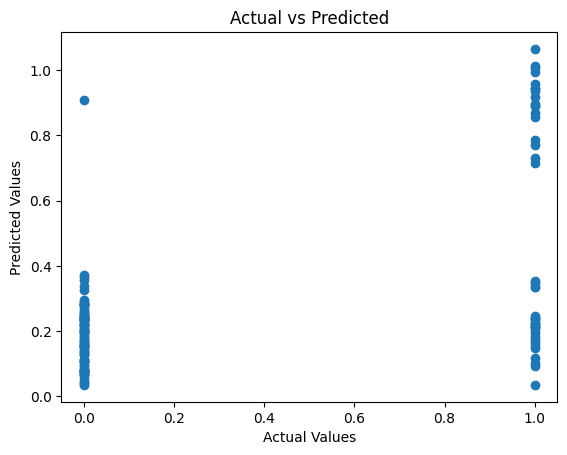

In [34]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

In [35]:
#KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2

# Scaling (must be non-negative for chi2)
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Feature Selection (FIX k <= 5)
selector = SelectKBest(score_func=chi2, k=5)
X_train = selector.fit_transform(X_train, y_train)
X_test = selector.transform(X_test)

# Hyperparameter tuning
param_grid = {
    'n_neighbors': range(1, 31),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)

grid.fit(X_train, y_train)

# Best model
knn = grid.best_estimator_

# Prediction
y_pred = knn.predict(X_test)

# Results
print("Best Parameters:", grid.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Best Parameters: {'metric': 'euclidean', 'n_neighbors': 8, 'weights': 'distance'}
Accuracy: 0.7886178861788617
[[79  1]
 [25 18]]
              precision    recall  f1-score   support

           0       0.76      0.99      0.86        80
           1       0.95      0.42      0.58        43

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



[[79  1]
 [25 18]]


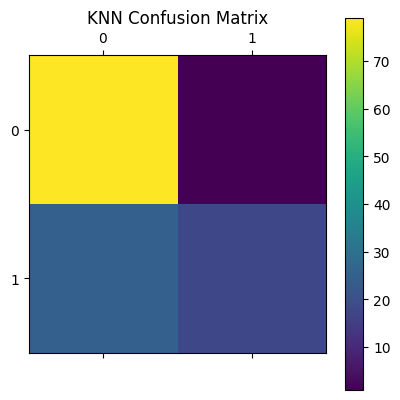

In [36]:
# prediction
y_pred_knn = knn.predict(X_test)

# confusion matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)

print(cm_knn)

plt.matshow(cm_knn)
plt.title("KNN Confusion Matrix")
plt.colorbar()
plt.show()